[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mlexchange/als_ml_tutorial/blob/main/3_4_ML_tutorial_CNN.ipynb)

## 1. Load the pretrained latent space encoder to convert images to latent vectors

In [1]:
import torch

device = torch.device("cuda:1") if torch.cuda.is_available() else torch.device("cpu")
print("Device:", device)

Device: cuda:1


In [3]:
#from torchsummary import summary
from model_utils import cnnAutoencoder

from tqdm import tqdm
from torch.utils.data import DataLoader, random_split
from torchvision import transforms

# auto_cnn = cnnAutoencoder(input_shape=(3, 128, 128), latent_dim=1000)
# auto_cnn.to(device)

# auto_cnn.load_state_dict(torch.load('./cnn_autoencoder_dl.pth'))
# auto_cnn.eval()


import mlflow
mlflow.set_tracking_uri(uri="http://127.0.0.1:8080")
model_name="tracking-quickstart"
model_version = "latest"
model_uri = f"models:/{model_name}/{model_version}"

# Load model
auto_cnn = mlflow.sklearn.load_model(model_uri)
auto_cnn.eval()

cnnAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=65536, out_features=1000, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=1000, out_features=65536, bias=True)
    (1): Unflatten(dim=1, unflattened_size=(64, 32, 32))
    (2): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(32, 3, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  )
)

In [4]:
import umap
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

def perform_umap(f_vec, n_neighbors=None, min_dist=None, random_state=None):
    # Perform U-MAP
    if n_neighbors is None and min_dist is None:
        umap_model = umap.UMAP(n_components=2, 
                               random_state=random_state)
    else:
        umap_model = umap.UMAP(n_components=2, 
                               n_neighbors=n_neighbors,
                               min_dist=min_dist,
                               random_state=random_state)
    umap_result = umap_model.fit_transform(f_vec)
    return umap_result

def plot_reduction(reduced_data, original_data, groups=None, category=None, zoom=0.35, savefig=False, outname=None):
    """ This function plots the dimensionally reduced data."""
    
    if 'pca' in category.lower():
        title = 'PCA Results'; xtitle = 'Principal Component 1'; ytitle = 'Principal Component 2'
    elif ('umap' in category.lower()) or ('u-map' in category.lower()):
        title = 'U-Map Results'; xtitle = 'U-Map Dimension 1'; ytitle = 'U-Map Dimension 2'
    else:
        title = 'Dimensionality Reduction Results'; xtitle = 'Reduced Dimension 1'; ytitle = 'Reduced Dimension 2'
    
    plt.figure(figsize=(10, 12))
    plt.rcParams.update({'font.size': 14})
    
    # Plot 2d reduction
    plt.subplot(2,1,1)
    if not groups:
        plt.scatter(reduced_data[:, 0], reduced_data[:, 1], alpha=0.5)
    else:
        # group colors
        #cs = ['y','red', 'green', 'lightcoral','limegreen','rosybrown','aquamarine','royalblue','deepskyblue','navy']
        cs =['red','darkgreen','magenta','greenyellow','pink','cyan']
        #cs = ['y','r', 'g', 'b']
        colors = [cs[i] for i in groups]
        plt.scatter(reduced_data[:, 0], reduced_data[:, 1], alpha=0.5, c=colors)
        #plt.legend(*scatter.legend_elements(),loc="lower left", title="Classes")
        
        
        #plt.legend((cs[0],cs[1],cs[2],cs[3]),['exp', 'generated_fake', 'generated_real', 'train_set'],loc='upper left',ncol=4)
        #plt.legend(loc='upper left',ncol=4)
        
    plt.title(title); plt.xlabel(xtitle); plt.ylabel(ytitle)
    plt.grid(True)

    # Plot 2d reduction with original images
    plt.subplot(2,1,2)
    scatter = plt.scatter(reduced_data[:, 0], reduced_data[:, 1], marker='o', s=30, c='b')
    
    for i in range(len(reduced_data)):

        if original_data[i].shape[0] > 1:
            orig_im = original_data[i][0,:]
        else:
            orig_im = original_data[i]
            
        imagebox = OffsetImage(orig_im, zoom=zoom)  # Adjust the zoom factor as needed
        ab = AnnotationBbox(imagebox, (reduced_data[i, 0], reduced_data[i, 1]), frameon=False)
        plt.gca().add_artist(ab)

    plt.title('Original Images Embedded')
    plt.xlabel(xtitle); plt.ylabel(ytitle); plt.title(title + ' with Original Images')
    plt.grid(True)

    plt.tight_layout()
    if savefig:
        plt.savefig(outname)
    plt.show()
    
    
    pass

# 2.Explore and visualize the latent space with UMAP

In [5]:
import torchvision.datasets as dset
import numpy as np

input_size = 128
data_transform=transforms.Compose([transforms.Resize(input_size),
                              transforms.CenterCrop(input_size),
                              transforms.ToTensor(),
                              transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
                             ])


# sorted paths, alphabetic order
mix_datasets = dset.ImageFolder(root="/lovelace/xiaoya/GenAI_dataset/dynamic_latent/testset/", transform=data_transform)
val_loader_mix = DataLoader(mix_datasets, batch_size=16, shuffle=False)

f_vec = []
groups = []
val_set_mix = []
with torch.no_grad(): 
    for batch, gs in val_loader_mix:
        batch_f_vec = auto_cnn.encoder(batch.to(device))
        f_vec.append(batch_f_vec.detach().cpu().numpy())
        groups.extend(gs)
        val_set_mix.append(batch)
        
f_vec = np.vstack(f_vec)
val_set_mix = np.vstack(val_set_mix)

print(val_set_mix.shape)
print(f_vec.shape)
print(len(groups))


(10, 3, 128, 128)
(10, 1000)
10


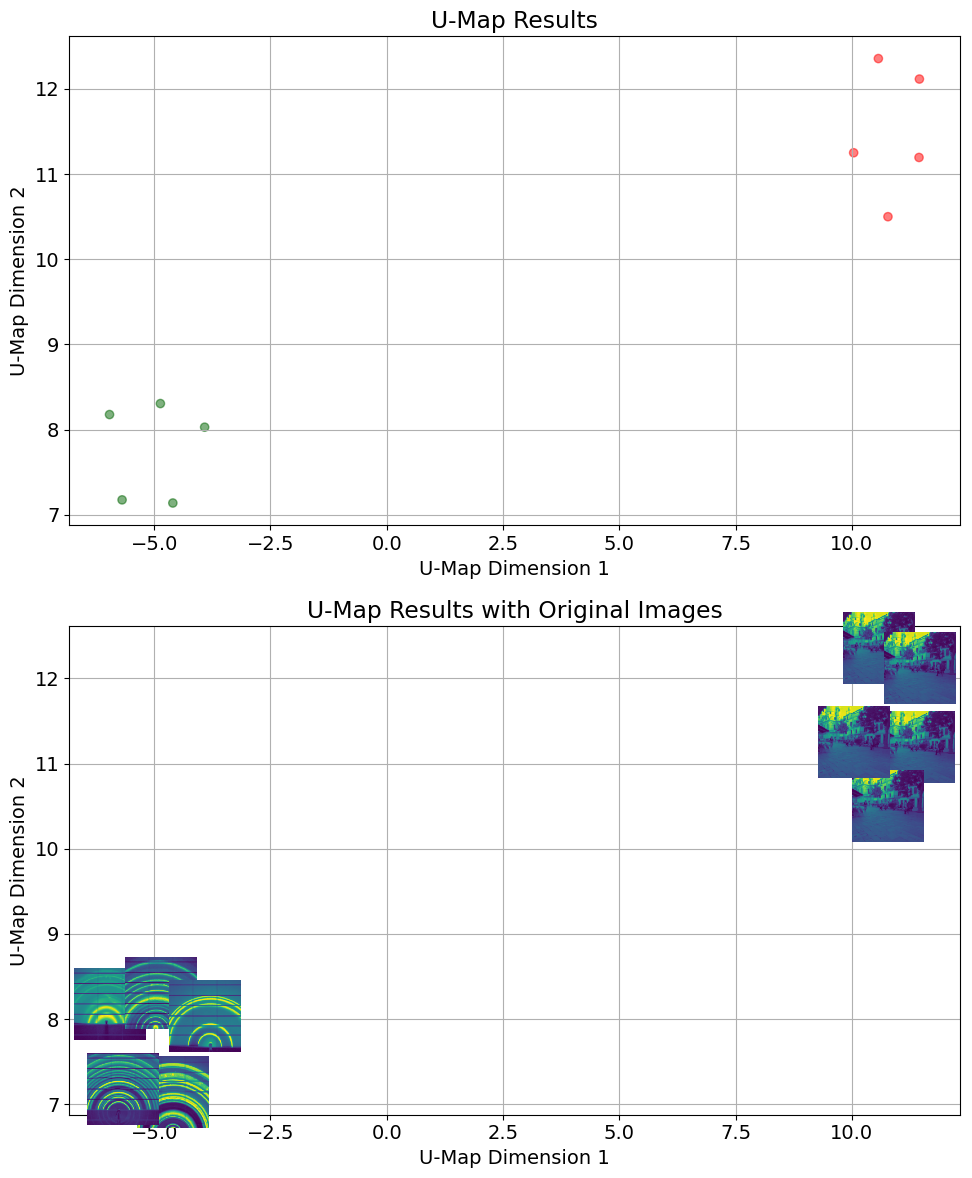

In [6]:
import matplotlib.pyplot as plt
import matplotlib
from PIL import Image

umap_features = perform_umap(f_vec, n_neighbors=5, min_dist=0.5)
plot_reduction(umap_features, np.squeeze(val_set_mix), groups=groups, category='umap', zoom=0.4, savefig=True, outname='./autoencoder_img_128/all_latent_space_mix.png')

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

optimal_clusters = 2
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
kmeans.fit(f_vec)

# Get the cluster labels
cluster_labels = kmeans.labels_

# Print the cluster labels
print(cluster_labels)




[0 0 0 0 0 1 1 1 1 1]


In [8]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
from model_utils import myModels
import torch
from torchvision import transforms
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def select_model(index):
    model_names = ["classification", "detection"]
    model_name = model_names[cluster_labels[index]]

    if model_name=="classification":
        folder_name="classifier_checkpoints_rings"
        model_name ="vit_p16"
    
        round_info = 'round2'
        num_classes = 2
        feature_extract = True
        input_size = 224
        round2_dir = '/lovelace/xiaoya/scientific_txt2image-main/'+str(folder_name)+'/'+round_info+'/'
        model, input_size = myModels.initialize_model(model_name, num_classes, feature_extract, use_pretrained=True)
        model = torch.load(round2_dir + model_name + '/' + model_name + '_' + str(1000) + '_epochs_classifier.pth')
    
    
    else:
        # Load the pre-trained model
        model = fasterrcnn_resnet50_fpn(pretrained=True)
    model.eval()  # Set the model to evaluation mode
    return model

In [9]:
def load_and_transform_image(image_path):
    image = Image.open(image_path)
    transformed_image = transform(image)
    return transformed_image

transform=transforms.Compose([transforms.Resize(224),
                              transforms.CenterCrop(224),
                              transforms.ToTensor(),
                              transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
                             ])

index = 0
#load the index = 0 data (ring fake data)
datapath = "/lovelace/xiaoya/GenAI_dataset/dynamic_latent/testset/rings/image_50000.tif"

model = select_model(index)
transformed_image = load_and_transform_image(datapath)
transformed_image= transformed_image.cuda()


output = model(transformed_image.unsqueeze(0))
ps = torch.exp(output)
probab = list(ps.cpu()[0])
pred_label = probab.index(max(probab))
print("classification result:", "real ring" if pred_label==1 else "fake ring")

Some weights of the model checkpoint at google/vit-base-patch16-224-in21k were not used when initializing ViTModel: ['pooler.dense.bias', 'pooler.dense.weight']
- This IS expected if you are initializing ViTModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing ViTModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


classification result: real ring


/home/xiaoya/miniconda3/envs/ensemble_classifier/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/xiaoya/miniconda3/envs/ensemble_classifier/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


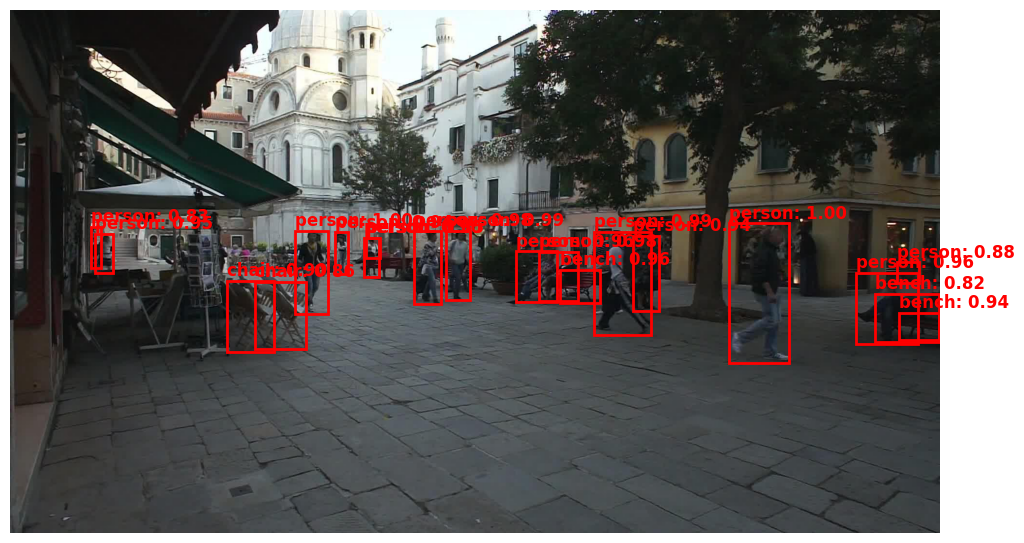

In [10]:

index = 6
# Load the image
image_path = "/lovelace/xiaoya/GenAI_dataset/dynamic_latent/testset/people/000101.jpg"
image = Image.open(image_path).convert("RGB")

# Define the transformation pipeline
transform = transforms.Compose([
    transforms.ToTensor()
])

# Apply the transformation
image_tensor = transform(image).unsqueeze(0)  # Add batch dimension

# Load the pre-trained model dynamically
model = select_model(index)

# Perform object detection
with torch.no_grad():
    predictions = model(image_tensor)

# Extract the boxes, labels, and scores
boxes = predictions[0]['boxes']
labels = predictions[0]['labels']
scores = predictions[0]['scores']

# Define the labels for COCO dataset
COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A',
    'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana',
    'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut',
    'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A', 'N/A',
    'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave',
    'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book', 'clock', 'vase', 'scissors',
    'teddy bear', 'hair drier', 'toothbrush'
]

# Set a threshold to filter out low-confidence detections
threshold = 0.8

# Plot the image with bounding boxes
fig, ax = plt.subplots(1, figsize=(12, 9))
ax.imshow(image)

# Draw bounding boxes and labels
for i in range(len(boxes)):
    if scores[i] > threshold:
        box = boxes[i].cpu().numpy()
        label = COCO_INSTANCE_CATEGORY_NAMES[labels[i]]
        score = scores[i].item()

        # Create a rectangle patch
        rect = patches.Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1],
                                 linewidth=2, edgecolor='r', facecolor='none')

        # Add the patch to the Axes
        ax.add_patch(rect)
        ax.text(box[0], box[1] - 10, f'{label}: {score:.2f}', color='red', fontsize=12, weight='bold')

plt.axis('off')
plt.show()